In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib

def create_variable_sequences(
    input_file="nafld_preprocessed_timeseries.csv", 
    min_timesteps=2, 
    max_timesteps=6, 
    test_size=0.2
):
    df = pd.read_csv(input_file)


    target_col = 'nafld_status'
    feature_cols = [col for col in df.columns if col not in ['id', 'days', 'nafld_event', 'nafld_status']]
    print(f"Features: {feature_cols}")


    scaler = StandardScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])
    joblib.dump(scaler, 'scaler.pkl') 

    X_sequences = []
    y_sequences = []
    
    grouped = df.groupby('id')
    
    for _, group_df in grouped:
        features = group_df[feature_cols].values
        target = group_df[target_col].values
        
        
        for t in range(min_timesteps, max_timesteps + 1):
            if len(features) > t:
                for i in range(len(features) - t):
                    X_sequences.append(features[i:(i + t)])
                    y_sequences.append(target[i + t])

    X_padded = pad_sequences(
        X_sequences, 
        maxlen=max_timesteps, 
        padding='pre', 
        dtype='float32', 
        value=0.0
    )
    
    y = np.array(y_sequences)

    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_padded, y, test_size=test_size, random_state=42, stratify=y
        )
    except ValueError as e:
        X_train, X_test, y_train, y_test = train_test_split(
            X_padded, y, test_size=test_size, random_state=42
        )
    
    np.save("X_train_variable.npy", X_train)
    np.save("y_train_variable.npy", y_train)
    np.save("X_test_variable.npy", X_test)
    np.save("y_test_variable.npy", y_test)
    
create_variable_sequences(min_timesteps=2, max_timesteps=6)

Loading preprocessed data from nafld_preprocessed_timeseries.csv...
Features: ['age_at_visit', 'male', 'bmi', 'hdl', 'chol', 'sbp', 'dbp', 'smoke', 'fib4']
Scaling features...
Saving the StandardScaler to 'scaler.pkl'...
Scaler saved!
Generating sequences from length 2 to 6...
Total sequences created (before padding): 70426
Padding all sequences to max_len=6...
Shape of X (padded sequences): (70426, 6, 9)
Shape of y (labels): (70426,)
Splitting and saving final arrays...
Data split successfully.

--- Variable Data Preparation Complete ---
Files created: X_train_variable.npy, y_train_variable.npy, X_test_variable.npy, y_test_variable.npy


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Masking
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# --- 1. Load Data ---
print("Loading data...")
try:
    X_train_full = np.load("X_train_variable.npy", allow_pickle=True)
    y_train_full = np.load("y_train_variable.npy", allow_pickle=True)
    X_test = np.load("X_test_variable.npy", allow_pickle=True)
    y_test = np.load("y_test_variable.npy", allow_pickle=True)
except FileNotFoundError:
    print("Error: data files not found.")
    exit()

classes = np.unique(y_train_full) 
weights = class_weight.compute_class_weight(
    'balanced',
    classes=classes,
    y=y_train_full
)
class_weights_dict = dict(zip(classes, weights))
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_full
)

n_timesteps = X_train.shape[1] 
n_features = X_train.shape[2] 

model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    Masking(mask_value=0.0),
    LSTM(units=50, return_sequences=True), 
    Dropout(0.2),
    LSTM(units=50, return_sequences=False), 
    Dropout(0.2),
    Dense(units=25, activation='tanh'),
    Dense(units=1, activation='sigmoid') 
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    verbose=1, 
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100, 
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights_dict, 
    callbacks=[early_stopping_callback],
    verbose=1
)

results = model.evaluate(X_test, y_test, verbose=1)
print(results)

model.save("phase3_var_lstm_1.keras")

Loading data...

Calculating class weights from the *full* training set...
Class weights (calculated from full set): {np.float64(0.0): np.float64(0.6273662643089395), np.float64(1.0): np.float64(2.462843154397622)}

Creating dedicated validation set...
Compiling model...
Training model...
Epoch 1/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.6272 - auc: 0.7207 - loss: 0.6114 - val_accuracy: 0.6125 - val_auc: 0.7397 - val_loss: 0.6225
Epoch 2/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.6573 - auc: 0.7704 - loss: 0.5671 - val_accuracy: 0.6945 - val_auc: 0.7809 - val_loss: 0.5497
Epoch 3/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.6981 - auc: 0.8023 - loss: 0.5340 - val_accuracy: 0.7116 - val_auc: 0.8224 - val_loss: 0.5359
Epoch 4/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.7290 - auc: 0.8315 - loss: 0.4984 - val_accuracy: 0.7594 - val_auc: 0.8484 - val_loss: 0.4811
Epoch 5/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 41s 20m

dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss'])


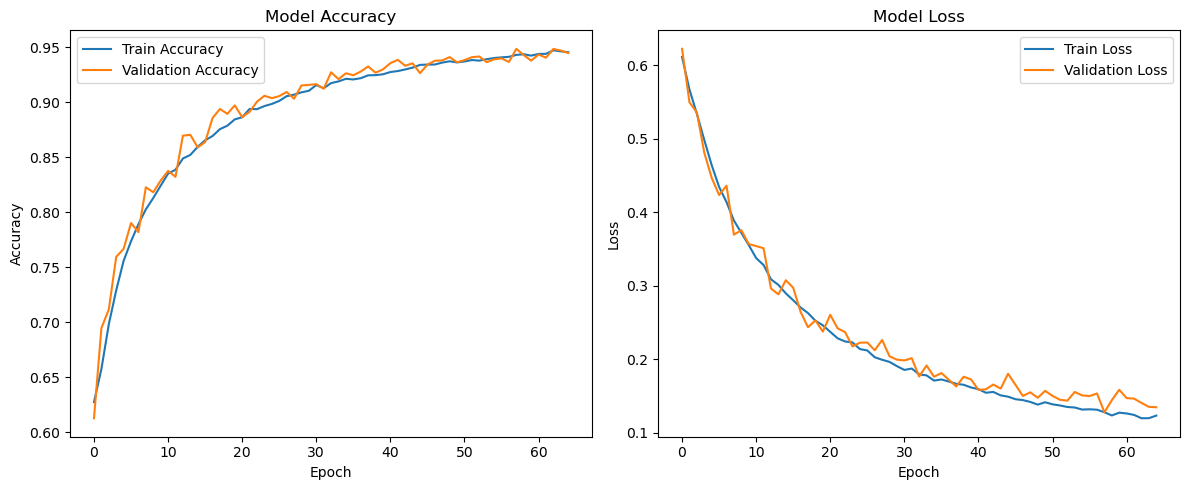

In [ ]:
print(history.history.keys())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # (1 row, 2 columns, 1st plot)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2) # (1 row, 2 columns, 2nd plot)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("model_training_history_final.png")

In [3]:
model.save("phase3_var_lstm_1.keras")